In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv


# TASK 3: Data Visualization - Final Version
# Dataset: Superstore Sales

In [3]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Visualization Settings

In [4]:
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10

# LOAD DATASET

In [5]:
df = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv', encoding='latin1')

# DATA CLEANING & FEATURE ENGINEERING

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

df['Discount Category'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 1],
    labels=[
        'No Discount',
        'Low (1-20%)',
        'Medium (21-40%)',
        'High (>40%)'
    ]
)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (9994, 26)

First 5 Rows:
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

                                        Product Name     Sales 

# VISUALIZATION 1: SALES BY REGION

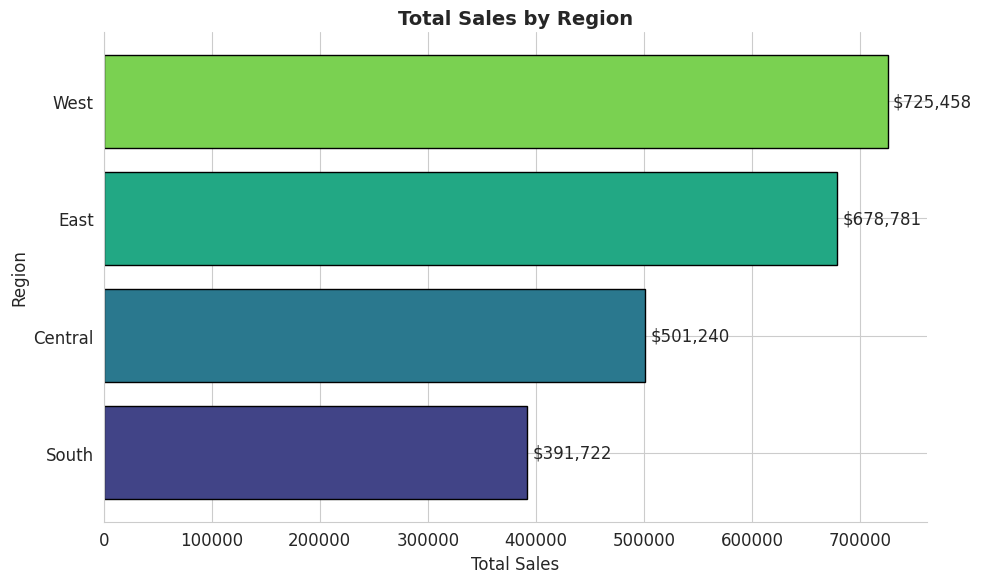

Insight: West region generated the highest sales.


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

region_sales = df.groupby('Region')['Sales'].sum().sort_values()

colors = sns.color_palette("viridis", n_colors=len(region_sales))

bars = ax.barh(
    region_sales.index,
    region_sales.values,
    color=colors,
    edgecolor='black'
)

ax.set_title('Total Sales by Region')
ax.set_xlabel('Total Sales')
ax.set_ylabel('Region')

for bar, val in zip(bars, region_sales.values):
    ax.text(
        val + 5000,
        bar.get_y() + bar.get_height()/2,
        f'${val:,.0f}',
        va='center'
    )

sns.despine()
plt.tight_layout()
plt.show()

print("Insight: West region generated the highest sales.")

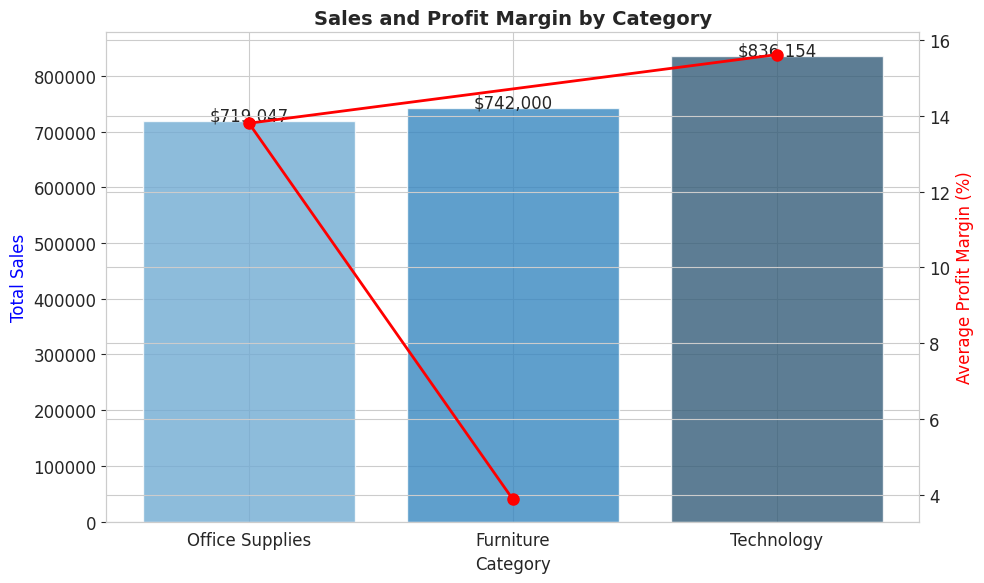

Insight: Technology category has the highest sales.


In [8]:
# VISUALIZATION 2: CATEGORY SALES & PROFIT MARGIN

fig, ax1 = plt.subplots(figsize=(10, 6))

category_sales = df.groupby('Category')['Sales'].sum().sort_values()

colors = sns.color_palette("Blues_d", n_colors=len(category_sales))

bars = ax1.bar(
    category_sales.index,
    category_sales.values,
    color=colors,
    alpha=0.8
)

ax1.set_xlabel('Category')
ax1.set_ylabel('Total Sales', color='blue')

ax2 = ax1.twinx()

category_margin = df.groupby('Category')['Profit Margin'].mean()

ax2.plot(
    category_margin.index,
    category_margin.values,
    'ro-',
    linewidth=2,
    markersize=8
)

ax2.set_ylabel('Average Profit Margin (%)', color='red')

for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1000,
        f'${bar.get_height():,.0f}',
        ha='center'
    )

plt.title('Sales and Profit Margin by Category')

plt.tight_layout()
plt.show()

print("Insight: Technology category has the highest sales.")

# VISUALIZATION 3: MONTHLY SALES TREND

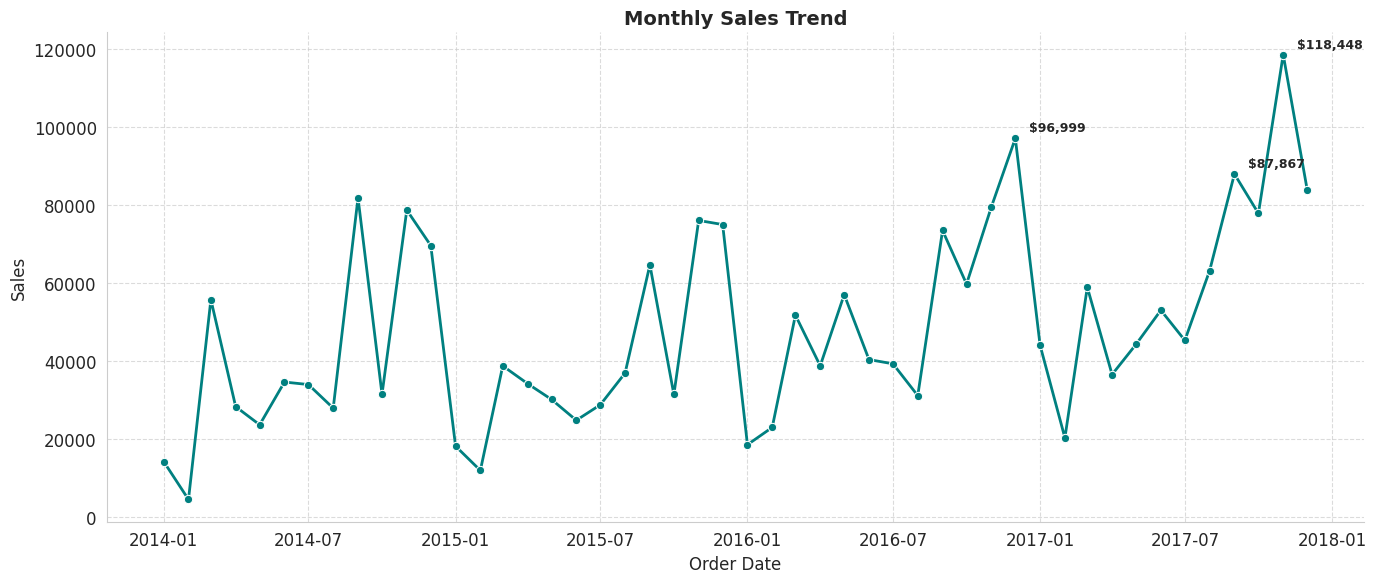

Insight: Sales increase significantly during year-end months.


In [9]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

monthly_sales['Date'] = pd.to_datetime(
    monthly_sales[['Year', 'Month']].assign(day=1)
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x='Date',
    y='Sales',
    marker='o',
    linewidth=2,
    color='teal'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Order Date')
plt.ylabel('Sales')

plt.grid(True, linestyle='--', alpha=0.7)

peaks = monthly_sales.nlargest(3, 'Sales')

for _, row in peaks.iterrows():
    plt.annotate(
        f'${row["Sales"]:,.0f}',
        xy=(row['Date'], row['Sales']),
        xytext=(10, 5),
        textcoords='offset points',
        fontsize=9,
        weight='bold'
    )

sns.despine()
plt.tight_layout()
plt.show()

print("Insight: Sales increase significantly during year-end months.")

# VISUALIZATION 4: YEARLY SALES GROWTH

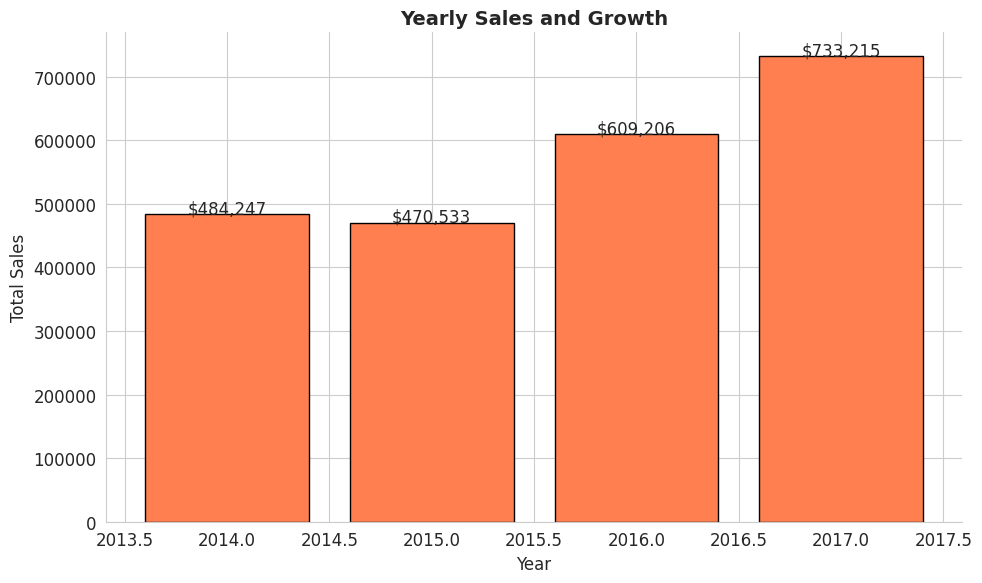

Insight: Sales growth improved significantly after 2015.


In [10]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

yearly_sales['Growth'] = yearly_sales['Sales'].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    yearly_sales['Year'],
    yearly_sales['Sales'],
    color='coral',
    edgecolor='black'
)

ax.set_title('Yearly Sales and Growth')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales')

for bar, year, sales in zip(
    bars,
    yearly_sales['Year'],
    yearly_sales['Sales']
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1000,
        f'${sales:,.0f}',
        ha='center'
    )

sns.despine()
plt.tight_layout()
plt.show()

print("Insight: Sales growth improved significantly after 2015.")

# VISUALIZATION 5: DISCOUNT VS PROFIT

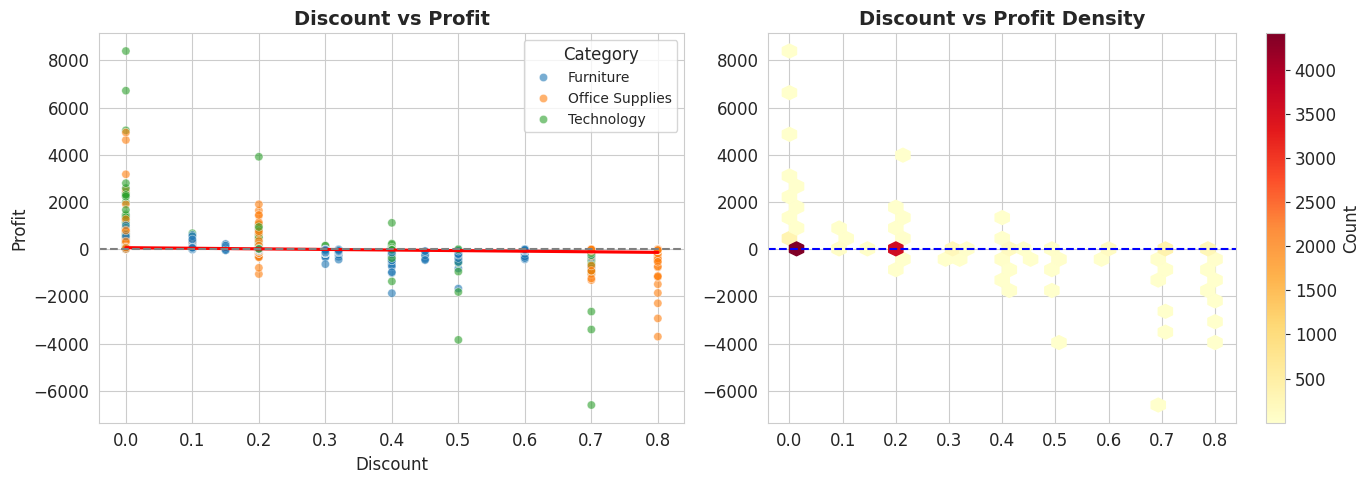

Insight: Higher discounts reduce profitability.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    alpha=0.6,
    ax=axes[0]
)

sns.regplot(
    data=df,
    x='Discount',
    y='Profit',
    scatter=False,
    color='red',
    ci=None,
    ax=axes[0]
)

axes[0].axhline(0, color='gray', linestyle='--')

axes[0].set_title('Discount vs Profit')

hb = axes[1].hexbin(
    df['Discount'],
    df['Profit'],
    gridsize=30,
    cmap='YlOrRd',
    mincnt=1
)

axes[1].axhline(0, color='blue', linestyle='--')

axes[1].set_title('Discount vs Profit Density')

plt.colorbar(hb, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

print("Insight: Higher discounts reduce profitability.")

# VISUALIZATION 6: PROFIT MARGIN BY DISCOUNT

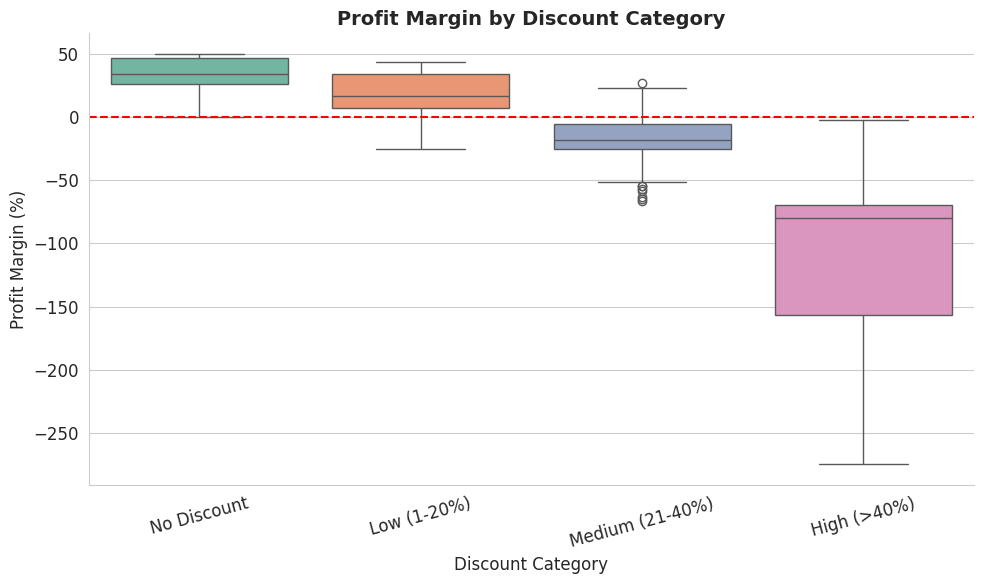

Insight: High discounts negatively affect profit margin.


In [12]:
plt.figure(figsize=(10, 6))

order = [
    'No Discount',
    'Low (1-20%)',
    'Medium (21-40%)',
    'High (>40%)'
]

sns.boxplot(
    data=df,
    x='Discount Category',
    y='Profit Margin',
    order=order,
    palette='Set2'
)

plt.axhline(0, color='red', linestyle='--')

plt.title('Profit Margin by Discount Category')
plt.xlabel('Discount Category')
plt.ylabel('Profit Margin (%)')

plt.xticks(rotation=15)

sns.despine()

plt.tight_layout()
plt.show()

print("Insight: High discounts negatively affect profit margin.")


# VISUALIZATION 7: REGION VS SEGMENT HEATMAP

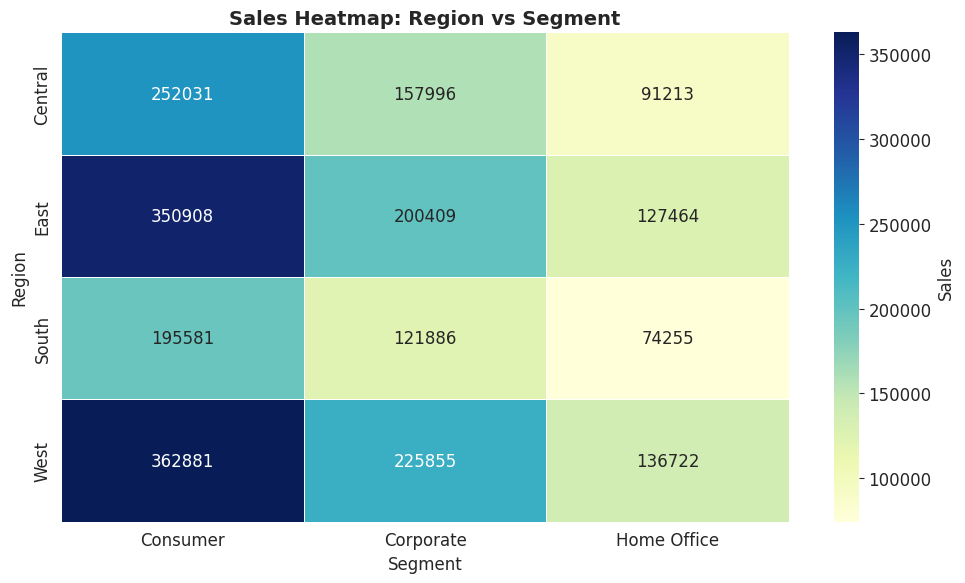

Insight: Consumer segment performs best in the West region.


In [13]:

pivot_sales = df.pivot_table(
    values='Sales',
    index='Region',
    columns='Segment',
    aggfunc='sum'
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_sales,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Sales'}
)

plt.title('Sales Heatmap: Region vs Segment')

plt.tight_layout()
plt.show()

print("Insight: Consumer segment performs best in the West region.")


# VISUALIZATION 8: TOP SUB-CATEGORIES

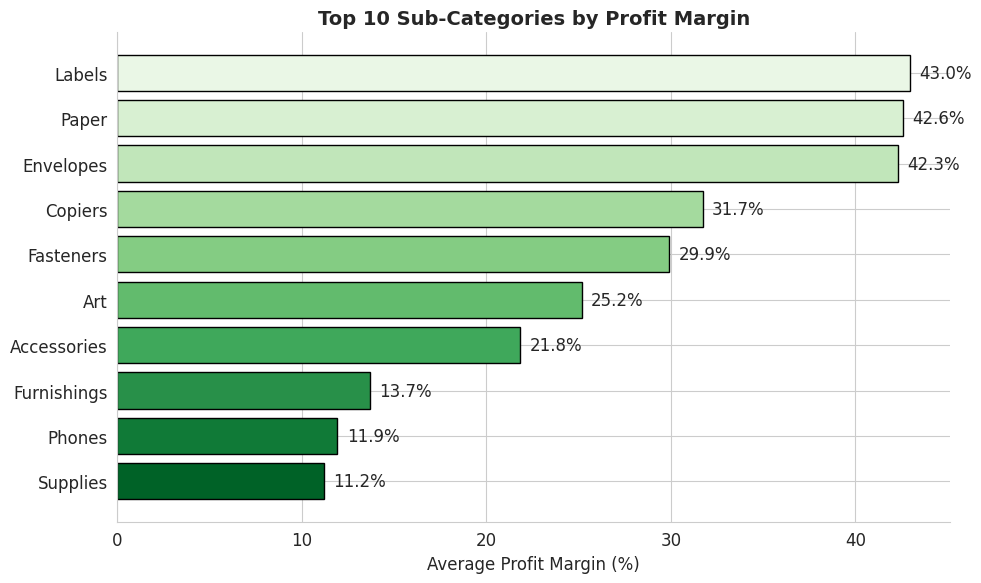

Insight: Copiers and Machines have strong profit margins.


In [14]:
top_margin = df.groupby('Sub-Category')['Profit Margin'] \
               .mean() \
               .nlargest(10) \
               .sort_values()

plt.figure(figsize=(10, 6))

colors = sns.color_palette(
    "Greens_r",
    n_colors=len(top_margin)
)

bars = plt.barh(
    top_margin.index,
    top_margin.values,
    color=colors,
    edgecolor='black'
)

plt.title('Top 10 Sub-Categories by Profit Margin')
plt.xlabel('Average Profit Margin (%)')

for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.1f}%',
        va='center'
    )

sns.despine()

plt.tight_layout()
plt.show()

print("Insight: Copiers and Machines have strong profit margins.")

# VISUALIZATION 9: CORRELATION HEATMAP

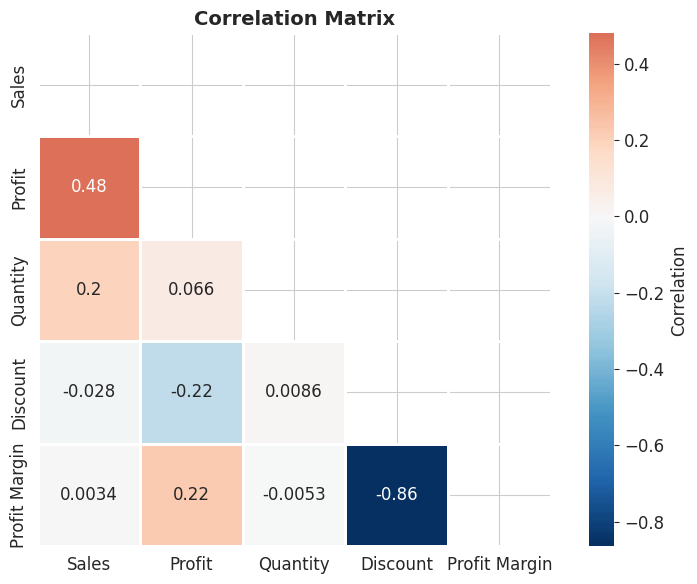

Key Correlations:
Sales vs Profit: Moderate positive correlation
Discount vs Profit: Negative correlation
Quantity vs Sales: Moderate positive correlation


In [15]:
numeric_cols = [
    'Sales',
    'Profit',
    'Quantity',
    'Discount',
    'Profit Margin'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=1,
    mask=mask,
    cbar_kws={'label': 'Correlation'}
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

print("Key Correlations:")
print("Sales vs Profit: Moderate positive correlation")
print("Discount vs Profit: Negative correlation")
print("Quantity vs Sales: Moderate positive correlation")

# VISUALIZATION 10: PAIRPLOT ANALYSIS

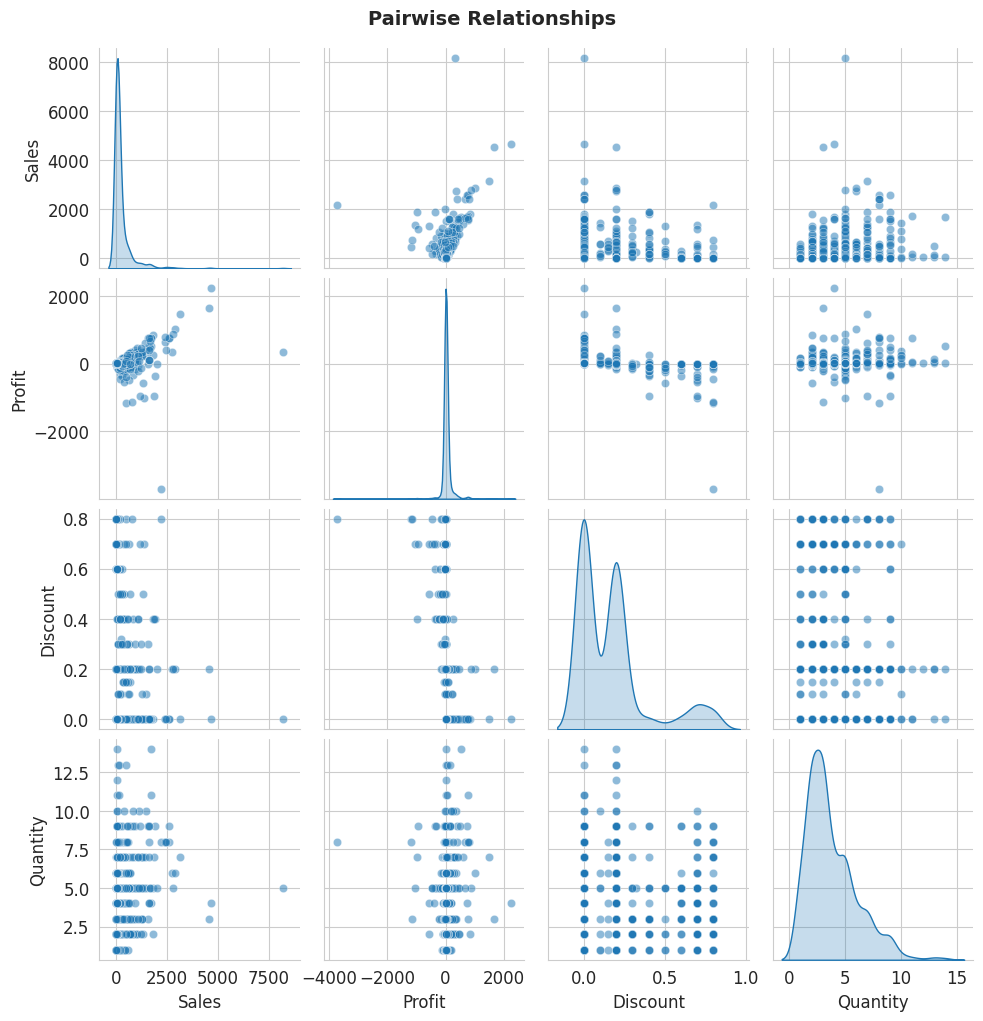

In [16]:
sample_df = df[
    ['Sales', 'Profit', 'Discount', 'Quantity']
].sample(1000)

sns.pairplot(
    sample_df,
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)

plt.suptitle(
    'Pairwise Relationships',
    y=1.02,
    fontsize=14,
    fontweight='bold'
)

plt.show()

# BUSINESS INSIGHTS

In [17]:
print("\nBusiness Recommendations:\n")

print("1. Increase marketing investment in West region.")
print("2. Prepare inventory before festive and year-end seasons.")
print("3. Avoid discounts greater than 40 percent.")
print("4. Promote high-margin product categories.")
print("5. Improve performance in South region through targeted campaigns.")


Business Recommendations:

1. Increase marketing investment in West region.
2. Prepare inventory before festive and year-end seasons.
3. Avoid discounts greater than 40 percent.
4. Promote high-margin product categories.
5. Improve performance in South region through targeted campaigns.
